# VGGT reconstruction vs. frame count, pose-space FPS sampling on ScanNet

For one ScanNet scene's posed color frames (`image_color/` + `pose/`, real camera-to-world poses — no video, no VSI-Bench mp4 involved), this notebook:

1. Runs greedy farthest-point-sampling **in real pose space** (translation + rotation distance) instead of the usual RGB-thumbnail-similarity FPS — the goal is directly "cover the most physical space with the fewest frames", which the thumbnail-based FPS only approximates.
2. Sweeps N = 8/12/16/24/32 frames, runs frozen VGGT on each set.
3. Scores each reconstruction against the scene's **official ScanNet mesh** (`_vh_clean_2.ply`, get it via `dataset/download_scannet_scene_mesh.sh`) via correspondence-free similarity-ICP + Chamfer/precision/recall/coverage — the same real-GT protocol validated in the VSI-Bench notebooks, not a VGGT self-reconstruction.
4. Visualizes every N's point cloud (+ GT) side by side, and plots quality vs. N to see where it plateaus.

No trimesh/plyfile — PLY read/write is hand-rolled (numpy only), matching the other notebooks.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
VGGT_ROOT = ROOT / "vggt"
for p in (ROOT, VGGT_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import torch
from PIL import Image
from scipy.spatial import cKDTree

from vggt.models.vggt import VGGT
from vggt.utils.load_fn import load_and_preprocess_images
from vggt.utils.pose_enc import pose_encoding_to_extri_intri

print("root:", ROOT)

root: /glob/g01-cache/pf/Yushuo/vjepa201


In [9]:
# ── config — edit this ──────────────────────────────────────────────────────
SPAR_ROOT = ROOT / "source_data/spar"
SCENE_NAME = "scene0011_00"
SCENE_ROOT = SPAR_ROOT / "scannet/images" / SCENE_NAME   # has image_color/, pose/
MESH_ROOT = ROOT / "source_data/scannet_mesh/scans" / SCENE_NAME  # has .../scans/.../*_vh_clean_2.ply

FRAME_COUNTS = [8, 12, 16, 24, 32]
POSE_ROT_WEIGHT = 1.0     # how much rotation (in units of 180deg) counts vs. translation (meters) in FPS distance
CONF_THRES = 2.0          # ScanNet's own color frames are clean stills (not compressed video),
                          # so the demo_colmap.py default should behave normally here -- but the
                          # conf-stats print below still runs every iteration, watch it.
IMG_EXTS = (".jpg", ".jpeg", ".png")

VGGT_CKPT = ROOT / "ckpts/vggt.pt"
OUTPUT_DIR = ROOT / "outputs/vggt_scannet_pose_fps_ablation" / SCENE_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if device.type == "cuda" and torch.cuda.get_device_capability()[0] >= 8 else torch.float16
print("device:", device, "dtype:", dtype)

if device.type == "cpu" and max(FRAME_COUNTS) > 16:
    print(f"WARNING: device=cpu, max N={max(FRAME_COUNTS)}. VGGT's aggregator attends jointly over "
          f"the whole input at once -- this can be slow/OOM on CPU. Run on a GPU node for larger N.")

device: cpu dtype: torch.float16


## Helpers

- `load_all_scene_poses` reads every frame in `image_color/` + its matching `pose/{id}.txt` (4x4 camera-to-world, meters — raw ScanNet SensReader layout), dropping frames with invalid (inf/nan) poses.
- `pose_fps_indices` is the same greedy farthest-point-sampling algorithm as `dataset/extract_vsibench_frames.py`'s `_farthest_point_sample`, just with the "feature" swapped from an RGB thumbnail to `[camera center, rotation angle]` — so it greedily picks frames that are maximally far apart in real 6-DoF pose space, not "look different".
- PLY read/write, VGGT forward, and the ICP/reconstruction-metric functions are the same ones already validated in the VSI-Bench notebooks.

In [3]:
# ── ScanNet posed-frame loading + pose-space FPS ──────────────────────────────

def load_all_scene_poses(scene_root: Path, image_dir: str = "image_color", pose_dir: str = "pose"):
    """Scan every frame in scene_root/image_dir, keep only those with a valid pose.
    Returns (frame_ids, image_paths, poses) -- poses: (N, 4, 4) camera-to-world."""
    color_dir = scene_root / image_dir
    frame_ids_all = sorted(
        (p.stem for p in color_dir.iterdir() if p.suffix.lower() in IMG_EXTS), key=int
    )
    ids, paths, poses = [], [], []
    for fid in frame_ids_all:
        mat = np.loadtxt(scene_root / pose_dir / f"{fid}.txt")
        if not np.all(np.isfinite(mat)):
            continue
        ids.append(fid)
        paths.append(str(color_dir / f"{fid}.jpg"))
        poses.append(mat)
    return ids, paths, np.stack(poses)


def pose_fps_indices(poses: np.ndarray, n: int, rot_weight: float = 1.0) -> list[int]:
    """Greedy farthest-point-sampling in pose space (translation + rotation angle),
    same algorithm as dataset/extract_vsibench_frames.py's _farthest_point_sample,
    with an SO(3)-aware distance instead of an RGB-thumbnail distance."""
    centers = poses[:, :3, 3]
    rots = poses[:, :3, :3]
    N = len(poses)

    def rot_angle(i, j):
        R_ij = rots[i].T @ rots[j]
        return np.degrees(np.arccos(np.clip((np.trace(R_ij) - 1) / 2, -1, 1)))

    def dist(i, j):
        return np.linalg.norm(centers[i] - centers[j]) + rot_weight * rot_angle(i, j) / 180.0

    selected = [0]
    min_dist = np.array([dist(0, j) for j in range(N)])
    for _ in range(n - 1):
        next_idx = int(np.argmax(min_dist))
        selected.append(next_idx)
        new_dist = np.array([dist(next_idx, j) for j in range(N)])
        min_dist = np.minimum(min_dist, new_dist)
    return sorted(selected)


# ── hand-rolled PLY I/O (no trimesh/plyfile) ──────────────────────────────────
_PLY_TYPE_MAP = {
    "float": "f4", "float32": "f4", "double": "f8", "float64": "f8",
    "uchar": "u1", "uint8": "u1", "char": "i1", "int8": "i1",
    "short": "i2", "int16": "i2", "ushort": "u2", "uint16": "u2",
    "int": "i4", "int32": "i4", "uint": "u4", "uint32": "u4",
}


def read_ply_vertices(path):
    with open(path, "rb") as f:
        assert f.readline().decode("ascii").strip() == "ply"
        fmt, n_vertices, properties, in_vertex = None, 0, [], False
        while True:
            line = f.readline().decode("ascii").strip()
            if line.startswith("format"):
                fmt = line.split()[1]
            elif line.startswith("element vertex"):
                n_vertices = int(line.split()[-1])
                in_vertex = True
            elif line.startswith("element"):
                in_vertex = False
            elif line.startswith("property") and in_vertex:
                _, ptype, pname = line.split()
                properties.append((pname, ptype))
            elif line == "end_header":
                break
        dtype = np.dtype([(name, _PLY_TYPE_MAP[t]) for name, t in properties])
        if fmt == "ascii":
            data = np.loadtxt(f, dtype=dtype, max_rows=n_vertices)
        else:
            dtype = dtype.newbyteorder("<" if fmt == "binary_little_endian" else ">")
            data = np.fromfile(f, dtype=dtype, count=n_vertices)
    pts = np.stack([data["x"], data["y"], data["z"]], axis=-1).astype(np.float64)
    colors = (np.stack([data["red"], data["green"], data["blue"]], axis=-1).astype(np.uint8)
              if "red" in data.dtype.names else np.full((len(pts), 3), 128, dtype=np.uint8))
    return pts, colors


def write_ply_ascii(pts, colors, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {len(pts)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
        f.write("end_header\n")
        for p, c in zip(pts, colors):
            f.write(f"{p[0]} {p[1]} {p[2]} {int(c[0])} {int(c[1])} {int(c[2])}\n")


# ── VGGT forward + point cloud extraction ─────────────────────────────────────
@torch.no_grad()
def run_vggt(model, image_paths):
    images = load_and_preprocess_images(image_paths).to(device)
    with torch.autocast(device_type=device.type, dtype=dtype, enabled=device.type == "cuda"):
        predictions = model(images)
    extrinsic, intrinsic = pose_encoding_to_extri_intri(predictions["pose_enc"], images.shape[-2:])
    predictions["extrinsic"] = extrinsic
    predictions["intrinsic"] = intrinsic
    return {k: (v.squeeze(0).float().cpu().numpy() if isinstance(v, torch.Tensor) else v)
            for k, v in predictions.items()}


def extract_pointcloud(preds, conf_thres):
    pts, conf, imgs = preds["world_points"], preds["world_points_conf"], preds["images"]
    mask = conf > conf_thres
    return pts[mask], (imgs.transpose(0, 2, 3, 1)[mask] * 255).astype(np.uint8)


# ── correspondence-free similarity alignment (coarse init + ICP w/ scale) ────
def coarse_align(src, dst):
    src_c, dst_c = src - src.mean(0), dst - dst.mean(0)
    scale = np.linalg.norm(dst_c, axis=1).std() / max(np.linalg.norm(src_c, axis=1).std(), 1e-8)
    return src_c * scale + dst.mean(0)


def umeyama_alignment(src, dst, with_scale=True):
    n = src.shape[0]
    mu_src, mu_dst = src.mean(axis=0), dst.mean(axis=0)
    src_c, dst_c = src - mu_src, dst - mu_dst
    cov = (dst_c.T @ src_c) / n
    U, D, Vt = np.linalg.svd(cov)
    S = np.eye(3)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[2, 2] = -1
    R = U @ S @ Vt
    s = np.trace(np.diag(D) @ S) / ((src_c ** 2).sum() / n) if with_scale else 1.0
    t = mu_dst - s * R @ mu_src
    return R, t, s


def icp_with_scale(src, dst, max_iters=50, tol=1e-6, max_dst_points=50000, max_src_points=20000, seed=0):
    rng = np.random.default_rng(seed)
    dst_sub = dst[rng.choice(len(dst), max_dst_points, replace=False)] if len(dst) > max_dst_points else dst
    src_idx = rng.choice(len(src), max_src_points, replace=False) if len(src) > max_src_points else np.arange(len(src))
    cur = src[src_idx].copy()
    tree = cKDTree(dst_sub)
    prev_err = np.inf
    for _ in range(max_iters):
        dists, idxs = tree.query(cur)
        R, t, s = umeyama_alignment(cur, dst_sub[idxs], with_scale=True)
        cur = (s * (R @ cur.T).T) + t
        err = float(dists.mean())
        if abs(prev_err - err) < tol:
            break
        prev_err = err
    return cur, err, src_idx


def reconstruction_metrics(src_pts, gt_pts, threshold=None, seed=0):
    if threshold is None:
        threshold = 0.01 * np.linalg.norm(gt_pts.max(0) - gt_pts.min(0))
    rng = np.random.default_rng(seed)
    gt_sub = gt_pts[rng.choice(len(gt_pts), min(len(gt_pts), 50000), replace=False)]
    src_sub = src_pts[rng.choice(len(src_pts), min(len(src_pts), 20000), replace=False)] if len(src_pts) > 20000 else src_pts
    dist_s2g, _ = cKDTree(gt_sub).query(src_sub)
    dist_g2s, _ = cKDTree(src_sub).query(gt_sub)
    precision = float((dist_s2g < threshold).mean())
    recall = float((dist_g2s < threshold).mean())
    return {
        "mean_dist_src_to_gt": float(dist_s2g.mean()),
        "mean_dist_gt_to_src": float(dist_g2s.mean()),
        "chamfer": float(dist_s2g.mean() + dist_g2s.mean()),
        "precision": precision, "recall": recall,
        "f_score": 2 * precision * recall / max(precision + recall, 1e-8),
    }


def coverage_extent(src_pts, gt_pts):
    src_extent = src_pts.max(0) - src_pts.min(0)
    gt_extent = gt_pts.max(0) - gt_pts.min(0)
    return {
        "per_axis_coverage": (src_extent / gt_extent).round(3).tolist(),
        "volume_ratio": float(np.prod(src_extent) / np.prod(gt_extent)),
    }


# ── plotting ───────────────────────────────────────────────────────────────
def scatter3d(pts, colors, name, max_points=30000):
    import plotly.graph_objects as go
    if len(pts) > max_points:
        idx = np.random.default_rng(0).choice(len(pts), max_points, replace=False)
        pts, colors = pts[idx], colors[idx]
    return go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2], mode="markers", name=name,
        marker=dict(size=1.5, color=[f"rgb({r},{g},{b})" for r, g, b in colors]),
    )

## Load VGGT (once) + scene poses + GT mesh

In [10]:
print(f"loading VGGT from {VGGT_CKPT} ...")
model = VGGT()
state = torch.load(VGGT_CKPT, map_location="cpu", weights_only=True)
model.load_state_dict(state)
model.eval().to(device)
print("loaded.")

frame_ids, frame_paths, poses = load_all_scene_poses(SCENE_ROOT)
print(f"scene {SCENE_NAME}: {len(frame_ids)} posed frames available")

mesh_path = next(MESH_ROOT.rglob("*_vh_clean_2.ply"))
print(f"GT mesh: {mesh_path}")
gt_pts, _ = read_ply_vertices(mesh_path)
if len(gt_pts) > 500000:
    idx = np.random.default_rng(SEED).choice(len(gt_pts), 500000, replace=False)
    gt_pts = gt_pts[idx]
gt_scale = float(np.linalg.norm(gt_pts.max(0) - gt_pts.min(0)))
print(f"GT points (subsampled): {len(gt_pts)}  |  gt_scale (bbox diagonal) = {gt_scale:.4f}")

loading VGGT from /glob/g01-cache/pf/Yushuo/vjepa201/ckpts/vggt.pt ...
loaded.
scene scene0011_00: 91 posed frames available
GT mesh: /glob/g01-cache/pf/Yushuo/vjepa201/source_data/scannet_mesh/scans/scene0011_00/scene0011_00_vh_clean_2.ply
GT points (subsampled): 237360  |  gt_scale (bbox diagonal) = 10.4392


## Sweep: pose-space FPS at N = 8/12/16/24/32

In [11]:
rows = []
clouds = {}   # name -> (aligned_pts, colors) for visualization

for n in FRAME_COUNTS:
    n = min(n, len(frame_ids))
    idx = pose_fps_indices(poses, n, rot_weight=POSE_ROT_WEIGHT)
    sampled_paths = [frame_paths[i] for i in idx]
    print(f"\n=== n={n}: frame_ids={[frame_ids[i] for i in idx]} ===")

    preds = run_vggt(model, sampled_paths)
    conf_all = preds["world_points_conf"]
    print(f"conf: min={conf_all.min():.3f} mean={conf_all.mean():.3f} max={conf_all.max():.3f}")

    pts, colors = extract_pointcloud(preds, CONF_THRES)
    print(f"n={n}: {len(pts)} points survived conf_thres={CONF_THRES}")
    if len(pts) == 0:
        rows.append({"n_frames": n, "n_points_raw": 0})
        continue

    coarse = coarse_align(pts, gt_pts)
    aligned, _, src_idx = icp_with_scale(coarse, gt_pts, seed=SEED)
    metrics = reconstruction_metrics(aligned, gt_pts, seed=SEED)
    cov = coverage_extent(aligned, gt_pts)

    write_ply_ascii(pts, colors, OUTPUT_DIR / f"n{n:03d}.ply")
    clouds[f"n{n:03d}"] = (aligned, colors[src_idx])

    row = {"n_frames": n, "n_points_raw": len(pts)}
    row.update(metrics)
    row.update(cov)
    rows.append(row)
    print(f"n={n}: chamfer={metrics['chamfer']:.4f} recall={metrics['recall']:.4f} "
          f"f_score={metrics['f_score']:.4f} volume_ratio={cov['volume_ratio']:.4f}")

clouds["gt"] = (gt_pts, np.full((len(gt_pts), 3), 160, dtype=np.uint8))

df = pd.DataFrame(rows)
df["gt_scale"] = gt_scale
df.to_csv(OUTPUT_DIR / "metrics.csv", index=False)
df


=== n=8: frame_ids=['0', '1250', '1541', '1677', '1755', '1855', '2237', '2343'] ===
conf: min=1.000 mean=1.046 max=2.562
n=8: 5019 points survived conf_thres=2.0
n=8: chamfer=1.2329 recall=0.0182 f_score=0.0356 volume_ratio=0.4687

=== n=12: frame_ids=['0', '310', '1107', '1250', '1541', '1677', '1755', '1855', '2012', '2130', '2237', '2343'] ===
conf: min=1.000 mean=1.116 max=2.890
n=12: 21333 points survived conf_thres=2.0
n=12: chamfer=1.8384 recall=0.0085 f_score=0.0167 volume_ratio=0.2511

=== n=16: frame_ids=['0', '310', '786', '1107', '1250', '1326', '1462', '1541', '1677', '1755', '1855', '2012', '2056', '2130', '2237', '2343'] ===
conf: min=1.000 mean=1.243 max=3.350
n=16: 76788 points survived conf_thres=2.0
n=16: chamfer=1.8428 recall=0.0131 f_score=0.0257 volume_ratio=0.0415

=== n=24: frame_ids=['0', '310', '480', '643', '786', '1022', '1107', '1250', '1326', '1372', '1462', '1541', '1627', '1677', '1720', '1755', '1821', '1855', '1969', '2012', '2056', '2130', '2237', '

,n_frames,n_points_raw,mean_dist_src_to_gt,mean_dist_gt_to_src,chamfer,precision,recall,f_score,per_axis_coverage,volume_ratio,gt_scale
0,8,5019,0.070058,1.162832,1.232890,0.798565,0.01820,0.035589,"[0.974, 0.492, 0.978]",0.468715,10.439187
1,12,21333,0.130072,1.708324,1.838396,0.537750,0.00848,0.016697,"[0.946, 0.33, 0.805]",0.251091,10.439187
2,16,76788,0.070136,1.772646,1.842783,0.860000,0.01306,0.025729,"[0.455, 0.209, 0.436]",0.041471,10.439187
3,24,868712,0.135303,1.571956,1.707259,0.512200,0.04304,0.079407,"[0.551, 0.277, 0.587]",0.089381,10.439187
4,32,957787,0.141535,1.510190,1.651725,0.476900,0.04416,0.080835,"[0.602, 0.305, 0.576]",0.105872,10.439187


## Visualize: point cloud per N (aligned into GT frame) + GT

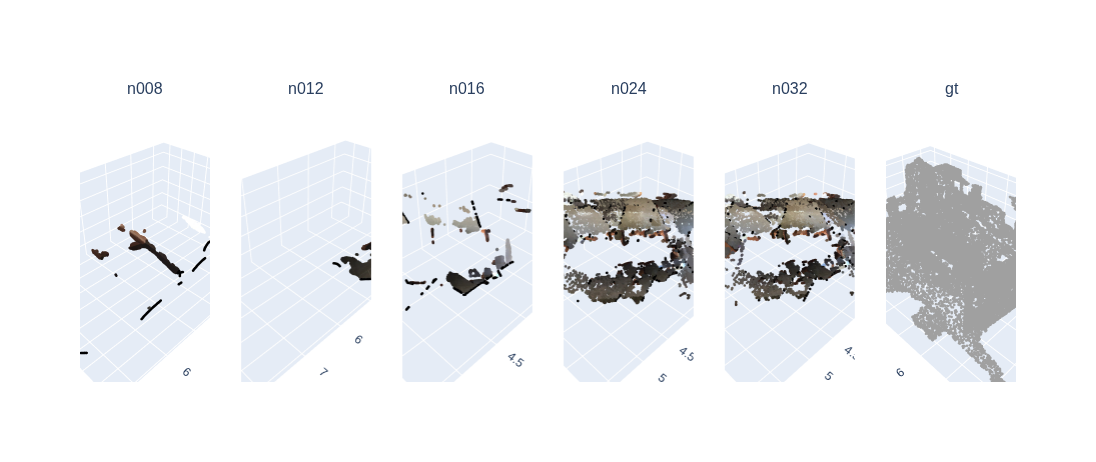

In [12]:
from plotly.subplots import make_subplots

panel_order = [f"n{n:03d}" for n in FRAME_COUNTS if f"n{n:03d}" in clouds] + ["gt"]
n_panels = len(panel_order)
fig = make_subplots(rows=1, cols=n_panels, specs=[[{"type": "scene"}] * n_panels],
                     subplot_titles=panel_order)
for col, name in enumerate(panel_order, start=1):
    pts, colors = clouds[name]
    fig.add_trace(scatter3d(pts, colors, name), row=1, col=col)

fig.update_layout(
    height=450, width=350 * n_panels, showlegend=False,
    **{f"scene{i if i > 1 else ''}": dict(aspectmode="data") for i in range(1, n_panels + 1)},
)
fig.show()

## Quality vs. N — where does it plateau?

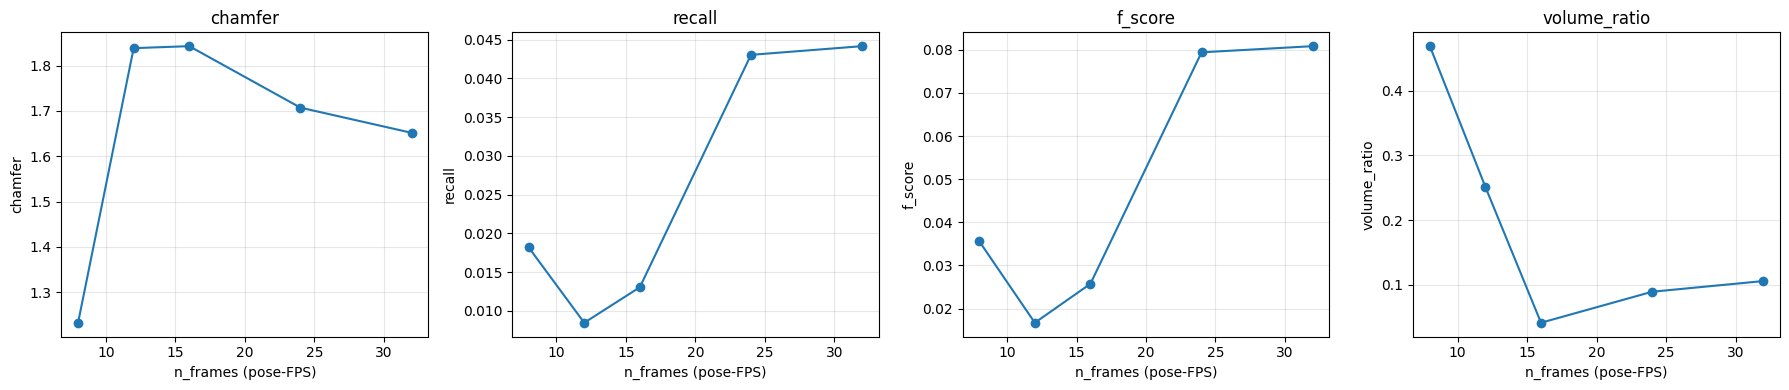


delta vs previous N:
   n_frames   chamfer   recall   f_score  volume_ratio
0       NaN       NaN      NaN       NaN           NaN
1       4.0  0.605506 -0.00972 -0.018892     -0.217624
2       4.0  0.004387  0.00458  0.009033     -0.209620
3       8.0 -0.135523  0.02998  0.053678      0.047910
4       8.0 -0.055534  0.00112  0.001427      0.016491


In [13]:
import matplotlib.pyplot as plt

metrics_to_plot = ["chamfer", "recall", "f_score", "volume_ratio"]
fig2, axes = plt.subplots(1, 4, figsize=(18, 4))
scored = df[df["n_points_raw"] > 0].sort_values("n_frames")
for ax, metric in zip(axes, metrics_to_plot):
    ax.plot(scored["n_frames"], scored[metric], marker="o")
    ax.set_xlabel("n_frames (pose-FPS)")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / "quality_vs_n.png", dpi=150)
plt.show()

print("\ndelta vs previous N:")
print(scored[["n_frames"] + metrics_to_plot].diff())